# <center> Cars Price Prediction
## <center> Feature engenniring and selection

<img src="Red-sport-car-isolated-on-transparent-background-PNG.png"     img>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn 
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,PolynomialFeatures
#from sklearn.linear_modele import LinearRegression
import seaborn as sns


#feature selection tools
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2

In [7]:
df=pd.read_csv("Car Price Data_After_EDA.csv")
df.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,mark_model,Year,Power,Location,Kilométrage,Boite_de_vitesses,Date,...,Non_fumeur,Système_d'identification_du_conducteur,Radar_de_recul,Limiteur_de_vitesse,Verrouillage_centralisé_à_distance,Mark,Model,Annonce Month,Annonce Day,Annonce Year
0,0,0,3,PEUGEOT 206,2002,Diesel,Chefchaouen,300000.0,Manuelle,2022-01-31,...,0,0,0,0,0,PEUGEOT,206,1,31,2022
1,1,1,4,NISSAN Micra,2021,Diesel,Casablanca,70000.0,Manuelle,2022-07-19,...,1,1,1,1,1,NISSAN,Micra,7,19,2022
2,2,2,7,HYUNDAI Santa fe,2016,Diesel,Casablanca,155000.0,Automatique,2022-04-15,...,1,1,0,0,0,HYUNDAI,Santa fe,4,15,2022
3,3,3,9,FIAT Ducato,2006,Diesel,Temara,154000.0,Manuelle,2021-11-22,...,0,0,0,0,0,FIAT,Ducato,11,22,2021
4,4,4,10,PEUGEOT Boxer,2016,Diesel,Nador,93000.0,Manuelle,2021-06-26,...,0,0,0,0,0,PEUGEOT,Boxer,6,26,2021


In [14]:
df["Price"].mean()

128688.05765605363

In [15]:
df[df["Annonce Year"]==2023]["Price"].mean()

147400.7926356589

In [3]:
df.drop(columns=["Link","mark_model","Date","Unnamed: 0.2","Unnamed: 0.1","Unnamed: 0"],inplace=True)

In [179]:
df.corr()["Price"].sort_values()

C:\Users\hp\AppData\Local\Temp\ipykernel_17460\4200615019.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()["Price"].sort_values()


Kilométrage                              -0.387751
Nombre_de_portes                         -0.018347
Annonce Day                              -0.005492
Annonce Month                             0.013675
Vitres_éléctriques                        0.103586
Dvd_cd_mp3                                0.104973
Annonce Year                              0.108612
Verrouillage_centralisé_à_distance        0.126108
Airbags                                   0.134213
Abs                                       0.182304
Non_fumeur                                0.190547
Alarme                                    0.196721
Direction_assistée                        0.198211
Climatisation_auto                        0.202145
Radar_de_recul                            0.235569
Jantes_aluminium                          0.244349
Limiteur_de_vitesse                       0.246031
Volant_reglable                           0.249064
Puissance_fiscale                         0.251234
Toit_ouvrant                   

In [180]:
# lets separate categorical columns  from numerical 
numerical_cols = df.select_dtypes(include=['int', 'float'])
categorical_cols =df.select_dtypes(include="object")


# 2- Select The Best Numerical Features 

## 2-1- Pearson's Correlation Coefficient

In [181]:
# define variables(X) and target (Y) 
X=numerical_cols.drop(columns=["Price"])
Y=df["Price"]
X.shape

(19096, 50)

In [182]:
# define feature selection
fs=SelectKBest(score_func=f_regression,k=50) # k is the number of features to select, here we select all to see the rank
fs

SelectKBest(k=50, score_func=<function f_regression at 0x0000011BAA694E50>)

In [183]:
# fit X and Y 
X_selected=fs.fit_transform(X,Y)
# shape of selected x
print(X_selected.shape)

(19096, 50)


In [184]:
#Get the indices of the selected features
feature_indices = fs.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = numerical_cols.columns[feature_indices].tolist()

#print(selected_feature_names)

In [185]:
# Get the scores (ANOVA F-value statistics) and p-values
scores = fs.scores_
p_values = fs.pvalues_

# Compute the rank and percentage of each feature
feature_rank = pd.Series(scores).rank(ascending=False)
#print(feature_rank)
feature_percentage =(scores / sum(scores)) * 100
#print(feature_percentage)

Text(0.5, 1.0, 'The best 20 numerical features')

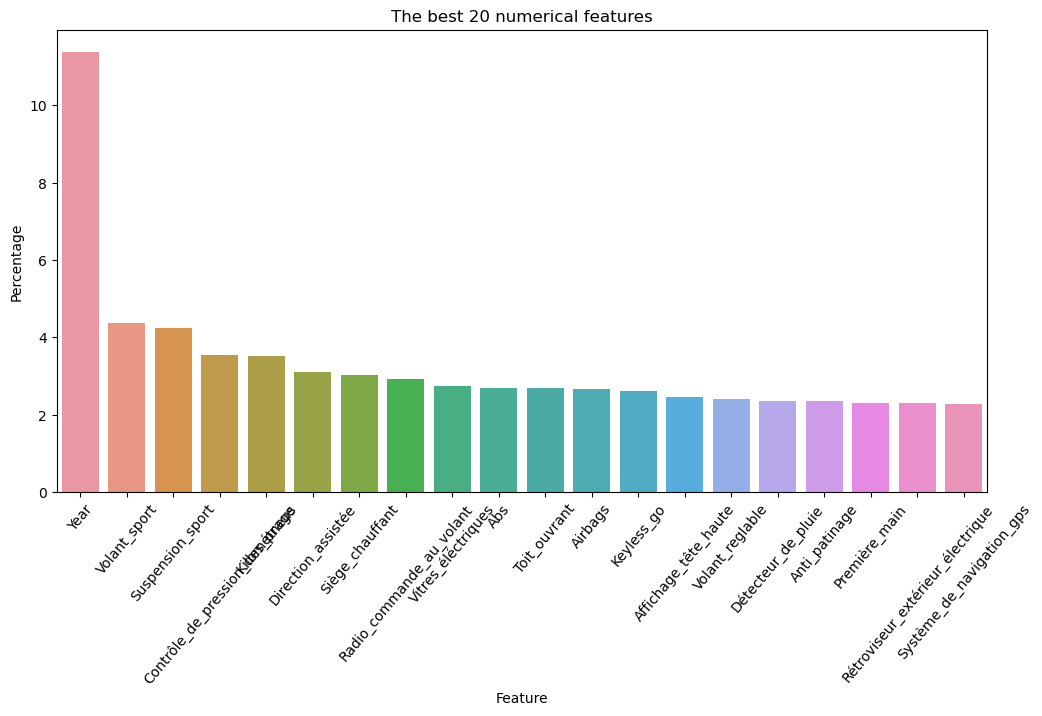

In [186]:
# Create a DataFrame to display the results
result_df = pd.DataFrame({'Feature': selected_feature_names,
                          'Score': scores,
                          'P-value': p_values,
                          'Rank': feature_rank,
                          'Percentage': feature_percentage})

result_df=result_df.sort_values(by="Rank")
result_df
plt.figure(figsize=(12,6))
plt.xticks(rotation=50)
sns.barplot(result_df.head(20),x="Feature",y="Percentage")
plt.title("The best 20 numerical features")


In [187]:
# the best 10 features:
X1_selected=list(result_df.head(10)["Feature"])
print("The best 10 numerical features are :",X1_selected)

The best 10 numerical features are : ['Year', 'Volant_sport', 'Suspension_sport', 'Contrôle_de_pression_des_pneus', 'Kilométrage', 'Direction_assistée', 'Siège_chauffant', 'Radio_commande_au_volant', 'Vitres_éléctriques', 'Abs']


# 2-2- Spearman's Rank Coefficient

In [188]:
# calculate the rank coefficient
rank_corr=X.corrwith(Y,method='spearman')
rank_corr_abs=np.abs(rank_corr)
rank_corr_sorted = rank_corr_abs.sort_values(ascending=False)
rank_corr_sorted

Year                                      0.727074
Contrôle_de_pression_des_pneus            0.446173
Kilométrage                               0.440156
Régulateur_de_vitesse                     0.428480
Détecteur_de_pluie                        0.410918
Anti_patinage                             0.394668
Frein_de_parking_automatique              0.388926
Ordinateur_de_bord                        0.383551
Aide_parking                              0.376749
Système_de_navigation_gps                 0.373294
Radio_commande_au_volant                  0.369694
Esp                                       0.354777
Carnet_d'entretien                        0.351899
Première_main                             0.346444
Anti_brouillard                           0.342828
Climatisation_multizone                   0.341236
Siége_electrique                          0.335642
Anti_démarrage                            0.331943
Keyless_go                                0.330612
Intérieur_cuir                 

In [189]:
# Select the top-k features with the highest absolute correlation coefficients
k = 10 
top_features = rank_corr_sorted[:k]
# Subset the dataset with the selected features
feature_selected = X[top_features.index]
X2_selected=feature_selected .columns.tolist()
# Print the selected features
print("Selected Features:")
print(X2_selected)

Selected Features:
['Year', 'Contrôle_de_pression_des_pneus', 'Kilométrage', 'Régulateur_de_vitesse', 'Détecteur_de_pluie', 'Anti_patinage', 'Frein_de_parking_automatique', 'Ordinateur_de_bord', 'Aide_parking', 'Système_de_navigation_gps']


In [190]:
set(X2_selected).difference(X1_selected)

{'Aide_parking',
 'Anti_patinage',
 'Détecteur_de_pluie',
 'Frein_de_parking_automatique',
 'Ordinateur_de_bord',
 'Régulateur_de_vitesse',
 'Système_de_navigation_gps'}

## 2-3- Mutual Informatiom

In [191]:
# Calculate mutual information between each predictor and the target
mutual_info = mutual_info_regression(X, Y)


In [192]:
#the mutual information scores for each predictor
feature_score=pd.DataFrame({"Feature":X.columns,"Score":mutual_info})
top10_feature_score=feature_score.sort_values(by="Score",ascending=False).head(10)
top10_feature_score

,Feature,Score
0,Year,0.425950
1,Kilométrage,0.126208
30,Contrôle_de_pression_des_pneus,0.111429
37,Régulateur_de_vitesse,0.106671
2,Puissance_fiscale,0.090801
31,Détecteur_de_pluie,0.090437
41,Frein_de_parking_automatique,0.089143
15,Anti_patinage,0.088642
36,Radio_commande_au_volant,0.087870
35,Ordinateur_de_bord,0.086196


In [193]:
# the top 10 selected features :
X3_selected=list(top10_feature_score["Feature"])
print ("The top 10 fearures selected by mutual information method are:",X3_selected)

The top 10 fearures selected by mutual information method are: ['Year', 'Kilométrage', 'Contrôle_de_pression_des_pneus', 'Régulateur_de_vitesse', 'Puissance_fiscale', 'Détecteur_de_pluie', 'Frein_de_parking_automatique', 'Anti_patinage', 'Radio_commande_au_volant', 'Ordinateur_de_bord']


In [194]:
set(X3_selected).difference(X2_selected)

{'Puissance_fiscale', 'Radio_commande_au_volant'}

# 3- Select The Best Categorical Features 

In [195]:
# define x and y
X=categorical_cols
Y=df["Price"]


#### let's  create a function to select  the top 10 categorical variables 

In [196]:
def feature_selector(encoder,selector,k):
    if  encoder=="OneHotEncoder":
        #print("OneHotEncoder: ")
        onehot_encoder = OneHotEncoder()
        X_encoded = onehot_encoder.fit_transform(X)
        # Convert the encoded features to a DataFrame
        X_encoded_df = pd.DataFrame(X_encoded.toarray(),
                            columns=onehot_encoder.get_feature_names_out(X.columns))
    else :
        #print("Label_Encoder:")
        X_encoded_df = X.apply(LabelEncoder().fit_transform)
        
    # Define the feature selector using ANOVA F-value
    sf = SelectKBest(score_func=selector, k=k)  # Choose the desired number of features

    # Fit the selector to the data
    sf.fit(X_encoded_df, Y)

    # Get the mask of selected features
    selected_mask = sf.get_support()

    # Get the names of the selected features
    selected_features = X_encoded_df.columns[selected_mask]

    # Print the names of the selected features
    
    # Get the scores (ANOVA F-value statistics) and p-values
    scores = sf.scores_
    p_values = sf.pvalues_

    # Compute the rank and percentage of each feature
    feature_rank = pd.Series(scores).rank(ascending=False)
    #print(feature_rank)
    feature_percentage = (scores / sum(scores)) * 100
    #print(feature_percentage)

    #put results in a dataframe:
    result_df = pd.DataFrame({'Feature': X_encoded_df.columns,
                          'Score': scores,
                          'P-value': p_values,
                          'Rank': feature_rank,
                          'Percentage': feature_percentage},index=None)

    result_df=result_df.sort_values(by="Rank",ascending=True).head(30)
    
    print("Seleceted Features :","\n",selected_features.to_list())
    return pd.DataFrame(result_df)
    



 ## ANOVA Correlation Coefficient

In [197]:
feature_selector("OneHotEncoder",f_regression,20)

Seleceted Features : 
 ['Power_Diesel', 'Power_Essence', 'Boite_de_vitesses_Automatique', 'Boite_de_vitesses_Manuelle', 'Carrosserie_Citadine', 'Carrosserie_Suv et 4x4', 'Mark_AUDI', 'Mark_BMW', 'Mark_DACIA', 'Mark_FIAT', 'Mark_LAND-ROVER', 'Mark_MERCEDES', 'Mark_PEUGEOT', 'Mark_VOLKSWAGEN', 'Model_Golf 7', 'Model_Logan', 'Model_Q5', 'Model_Range rover evoque', 'Model_Range rover sport', 'Model_Tiguan']


,Feature,Score,P-value,Rank,Percentage
103,Boite_de_vitesses_Automatique,10590.932151,0.000000e+00,1.0,21.102932
104,Boite_de_vitesses_Manuelle,10590.932151,0.000000e+00,2.0,21.102932
145,Carrosserie_Suv et 4x4,2887.449212,0.000000e+00,3.0,5.753379
2,Power_Essence,2229.068082,0.000000e+00,4.0,4.441523
0,Power_Diesel,2097.426263,0.000000e+00,5.0,4.179221
137,Carrosserie_Citadine,1670.400069,0.000000e+00,6.0,3.328351
181,Mark_LAND-ROVER,941.426077,7.530812e-202,7.0,1.875836
150,Mark_AUDI,907.831654,6.955802e-195,8.0,1.808897
668,Model_Tiguan,882.460876,1.290320e-189,9.0,1.758345
186,Mark_MERCEDES,742.540126,1.949698e-160,10.0,1.479546


In [198]:
feature_selector("LabelEncoder",f_regression,7)

Seleceted Features : 
 ['Power', 'Location', 'Boite_de_vitesses', 'Couleur', 'Carrosserie', 'Mark', 'Model']


,Feature,Score,P-value,Rank,Percentage
2,Boite_de_vitesses,10590.932151,0.000000e+00,1.0,74.628961
0,Power,2014.467958,0.000000e+00,2.0,14.194940
4,Carrosserie,1073.346190,4.357790e-229,3.0,7.563330
6,Model,477.500376,1.426614e-104,4.0,3.364704
1,Location,32.903298,9.832354e-09,5.0,0.231853
5,Mark,1.767910,1.836568e-01,6.0,0.012458
3,Couleur,0.532798,4.654417e-01,7.0,0.003754


### 3-2 Chi_Squared

 #### One Hot Encoder

In [199]:
feature_selector("OneHotEncoder",chi2,30)

Seleceted Features : 
 ['Power_Essence', 'Boite_de_vitesses_Automatique', 'Boite_de_vitesses_Manuelle', 'Carrosserie_Citadine', 'Carrosserie_Suv et 4x4', 'Mark_CHANA', 'Mark_LAND-ROVER', 'Model_309', 'Model_Atos', 'Model_Baleno', 'Model_Glc', 'Model_Golf', 'Model_Kadjar', 'Model_Lanos', 'Model_Marea', 'Model_Mokka', 'Model_Nomad', 'Model_Palio', 'Model_Range rover evoque', 'Model_Saxo', 'Model_Serie 2', 'Model_Serie 2 gran coupe', 'Model_Serie 4 gran coupe', 'Model_Shenqi', 'Model_Stelvio', 'Model_T-roc', 'Model_Tiguan', 'Model_Uno', 'Model_Xe', 'Model_Zx']


,Feature,Score,P-value,Rank,Percentage
635,Model_Shenqi,19095.000000,0.000000e+00,1.5,4.283784
239,Model_309,19095.000000,0.000000e+00,1.5,4.283784
625,Model_Serie 2 gran coupe,9980.000000,0.000000e+00,3.0,2.238919
154,Mark_CHANA,9652.088889,0.000000e+00,4.0,2.165356
688,Model_Uno,6815.315136,0.000000e+00,5.0,1.528952
103,Boite_de_vitesses_Automatique,5519.309456,0.000000e+00,6.0,1.238205
2,Power_Essence,4653.133051,0.000000e+00,7.0,1.043887
524,Model_Marea,4241.555556,0.000000e+00,8.0,0.951553
538,Model_Mokka,3920.487528,0.000000e+00,9.0,0.879525
727,Model_Zx,3181.666667,0.000000e+00,10.0,0.713777


#### Label Encoder

In [200]:
feature_selector("LabelEncoder",chi2,7)

Seleceted Features : 
 ['Power', 'Location', 'Boite_de_vitesses', 'Couleur', 'Carrosserie', 'Mark', 'Model']


,Feature,Score,P-value,Rank,Percentage
6,Model,88284.255623,0.000000e+00,1.0,71.649823
1,Location,10006.559680,0.000000e+00,2.0,8.121134
0,Power,8929.985977,0.000000e+00,3.0,7.247407
4,Carrosserie,7319.648033,0.000000e+00,4.0,5.940487
5,Mark,4855.902526,0.000000e+00,5.0,3.940958
2,Boite_de_vitesses,2005.266354,6.140055e-186,6.0,1.627436
3,Couleur,1814.674610,7.723693e-155,7.0,1.472755


## Mutual Info Regression

#### OneHotEncoder:

In [201]:
feature_selector("OneHotEncoder",mutual_info_regression,10)

Seleceted Features : 
 ['Power_Diesel', 'Power_Essence', 'Boite_de_vitesses_Automatique', 'Boite_de_vitesses_Manuelle', 'Carrosserie_Citadine', 'Carrosserie_Suv et 4x4', 'Mark_DACIA', 'Mark_MERCEDES', 'Model_Golf 7', 'Model_Logan']


,Feature,Score,P-value,Rank,Percentage
104,Boite_de_vitesses_Manuelle,0.192437,None,1.0,6.304374
103,Boite_de_vitesses_Automatique,0.181977,None,2.0,5.961695
2,Power_Essence,0.121718,None,3.0,3.987586
0,Power_Diesel,0.109986,None,4.0,3.603220
137,Carrosserie_Citadine,0.068824,None,5.0,2.254717
145,Carrosserie_Suv et 4x4,0.064753,None,6.0,2.121363
161,Mark_DACIA,0.026969,None,7.0,0.883522
519,Model_Logan,0.025159,None,8.0,0.824238
186,Mark_MERCEDES,0.024304,None,9.0,0.796203
452,Model_Golf 7,0.021373,None,10.0,0.700190


#### LabelEncoder

In [202]:
feature_selector("LabelEncoder",mutual_info_regression,5)

Seleceted Features : 
 ['Power', 'Boite_de_vitesses', 'Carrosserie', 'Mark', 'Model']


,Feature,Score,P-value,Rank,Percentage
2,Boite_de_vitesses,0.184776,None,1.0,41.557147
0,Power,0.118143,None,2.0,26.570956
4,Carrosserie,0.076430,None,3.0,17.189643
6,Model,0.026807,None,4.0,6.028999
5,Mark,0.015348,None,5.0,3.451927
3,Couleur,0.013167,None,6.0,2.961376
1,Location,0.009960,None,7.0,2.239952


In [203]:
#### So we will chose the following features:
cat_feat=['Power','Boite_de_vitesses','Carrosserie','Mark','Model']
num_feat=["Year",'Kilométrage','Puissance_fiscal']


## Feature Engennering:

In this section we will to produce some new features from the already existed ones.
-  age car feature from year.
- N_features will be the sum of all the car options.



In [209]:
df=df.drop(columns=["Location","Nombre_de_portes","Couleur",
                    'Annonce Month', 'Annonce Day', 'Annonce Year'])

KeyError: "['Location', 'Nombre_de_portes', 'Couleur', 'Annonce Month', 'Annonce Day', 'Annonce Year'] not found in axis"

In [210]:
from datetime import datetime
df["Age"]=datetime.now().year-df["Year"]
df.drop(columns=["Year"],inplace=True)

KeyError: 'Year'

In [211]:
features=['Dvd_cd_mp3',
       'Jantes_aluminium', 'Alarme', 'Airbags', 'Aide_parking',
       'Climatisation_auto', 'Abs', 'Système_de_navigation_gps',
       "Carnet_d'entretien", 'Vitres_éléctriques', 'Anti_patinage', 'Esp',
       'Capote_électrique', 'Projecteurs_xenon',
       'Rétroviseur_extérieur_électrique', 'Toit_ouvrant_panoramique',
       'Toit_ouvrant', 'Intérieur_cuir', 'Siège_chauffant', 'Siége_electrique',
       'Siége_sport', 'Vitres_surteintées', 'Volant_reglable',
       'Anti_démarrage', 'Volant_sport', 'Contrôle_de_pression_des_pneus',
       'Détecteur_de_pluie', 'Climatisation_multizone', 'Direction_assistée',
       'Keyless_go', 'Ordinateur_de_bord', 'Radio_commande_au_volant',
       'Régulateur_de_vitesse', 'Anti_brouillard', 'Affichage_tête_haute',
       'Suspension_sport', 'Frein_de_parking_automatique', 'Non_fumeur',
       "Système_d'identification_du_conducteur", 'Radar_de_recul',
       'Limiteur_de_vitesse', 'Verrouillage_centralisé_à_distance']
df["N_features"]=df[features].sum(axis=1)

In [212]:
df[["N_features","Price"]].corr()

,N_features,Price
N_features,1.00000,0.43497
Price,0.43497,1.00000


In [213]:
df.drop(columns=features,inplace=True)

In [214]:
df.head()

,Power,Kilométrage,Boite_de_vitesses,Puissance_fiscale,Première_main,Carrosserie,Price,Mark,Model,Age,N_features
0,Diesel,300000.0,Manuelle,7.0,0,Citadine,45000.0,PEUGEOT,206,21,5
1,Diesel,70000.0,Manuelle,6.0,1,Citadine,158000.0,NISSAN,Micra,2,31
2,Diesel,155000.0,Automatique,9.0,1,Suv et 4x4,225000.0,HYUNDAI,Santa fe,7,38
3,Diesel,154000.0,Manuelle,11.0,1,Utilitaire (van),300000.0,FIAT,Ducato,17,0
4,Diesel,93000.0,Manuelle,9.0,1,Utilitaire (van),162000.0,PEUGEOT,Boxer,7,16


In [238]:
num_features=df[['Kilométrage', 'Puissance_fiscale',
       'Première_main', 'Price','Age',
       'N_features']]
num_features.dtypes

Kilométrage          float64
Puissance_fiscale    float64
Première_main          int64
Price                float64
Age                    int64
N_features             int64
dtype: object

In [250]:
X=num_features.drop(columns=["Price"])
Y=num_features["Price"]
X

,Kilométrage,Puissance_fiscale,Première_main,Age,N_features
0,300000.0,7.0,0,21,5
1,70000.0,6.0,1,2,31
2,155000.0,9.0,1,7,38
3,154000.0,11.0,1,17,0
4,93000.0,9.0,1,7,16
...,...,...,...,...,...
19091,163000.0,6.0,0,17,0
19092,114000.0,9.0,1,8,21
19093,140000.0,8.0,1,7,14
19094,290000.0,12.0,1,14,33


In [251]:
# define feature selection
fs=SelectKBest(score_func=f_regression,k=5) # k is the number of features to select, here we select all to see the rank
fs

SelectKBest(k=5, score_func=<function f_regression at 0x0000011BAA694E50>)

In [253]:
# fit X and Y 
X_selected=fs.fit_transform(X,Y)
# shape of selected x
print(X_selected.shape)

(19096, 5)


array([[3.00e+05, 7.00e+00, 0.00e+00, 2.10e+01, 5.00e+00],
       [7.00e+04, 6.00e+00, 1.00e+00, 2.00e+00, 3.10e+01],
       [1.55e+05, 9.00e+00, 1.00e+00, 7.00e+00, 3.80e+01],
       ...,
       [1.40e+05, 8.00e+00, 1.00e+00, 7.00e+00, 1.40e+01],
       [2.90e+05, 1.20e+01, 1.00e+00, 1.40e+01, 3.30e+01],
       [1.29e+05, 8.00e+00, 0.00e+00, 1.00e+01, 1.30e+01]])

In [254]:
# Get the indices of the selected features
feature_indices = fs.get_support(indices=True)

# Get the names of the selected features
selected_feature_names = X.columns[feature_indices].tolist()

selected_feature_names

['Kilométrage', 'Puissance_fiscale', 'Première_main', 'Age', 'N_features']

In [255]:
# Get the scores (ANOVA F-value statistics) and p-values
scores = fs.scores_
p_values = fs.pvalues_

# Compute the rank and percentage of each feature
feature_rank = pd.Series(scores).rank(ascending=False)
print(feature_rank.shape)
feature_percentage = (scores / sum(scores)) * 100
print(feature_percentage.shape)

(5,)
(5,)


             Feature         Score        P-value  Rank  Percentage
3                Age  10973.202822   0.000000e+00   1.0   49.186159
4         N_features   4455.561253   0.000000e+00   2.0   19.971557
0        Kilométrage   3378.814989   0.000000e+00   3.0   15.145162
2      Première_main   2215.570648   0.000000e+00   4.0    9.931049
1  Puissance_fiscale   1286.384119  1.080186e-272   5.0    5.766074


Text(0.5, 1.0, 'The best 20 numerical features')

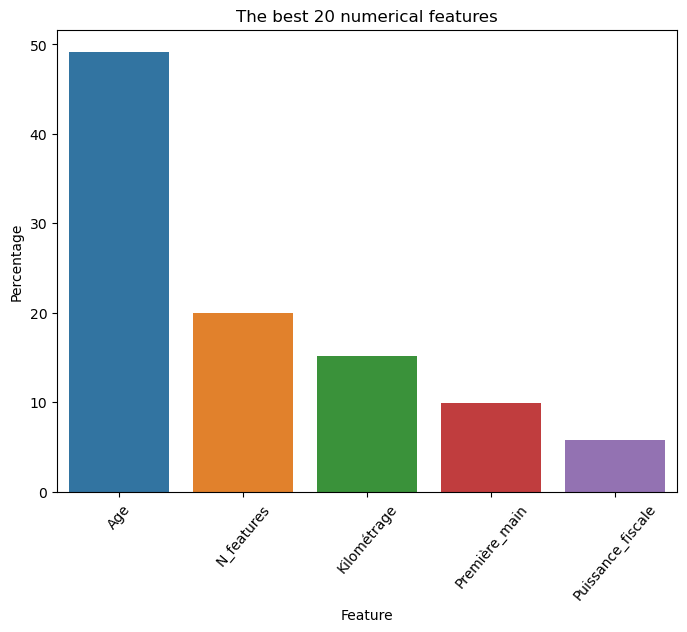

In [256]:
# Create a DataFrame to display the results
result_df = pd.DataFrame({'Feature': selected_feature_names,
                          'Score': scores,
                          'P-value': p_values,
                          'Rank': feature_rank,
                          'Percentage': feature_percentage})

result_df=result_df.sort_values(by="Rank")
print(result_df)
plt.figure(figsize=(8,6))
plt.xticks(rotation=50)
sns.barplot(result_df.head(20),x="Feature",y="Percentage")
plt.title("The best 20 numerical features")

## One Hot Encoder on all cat features:

In [307]:
df.to_csv("cars_data_after_feature_engenniring.csv")

In [306]:
onehot_df=pd.get_dummies(df)
onehot_df

,Kilométrage,Puissance_fiscale,Première_main,Price,Age,N_features,Power_Diesel,Power_Electrique,Power_Essence,Power_Hybride,...,Model_Xlv,Model_Xsara,Model_Xsara picasso,Model_Yaris,Model_Yaris cross,Model_Yeti,Model_Ypsilon,Model_Yrv,Model_Zafira,Model_Zx
0,300000.0,7.0,0,45000.0,21,5,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,70000.0,6.0,1,158000.0,2,31,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,155000.0,9.0,1,225000.0,7,38,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,154000.0,11.0,1,300000.0,17,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,93000.0,9.0,1,162000.0,7,16,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19091,163000.0,6.0,0,58000.0,17,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19092,114000.0,9.0,1,180000.0,8,21,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19093,140000.0,8.0,1,145000.0,7,14,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19094,290000.0,12.0,1,180000.0,14,33,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
le=LabelEncoder()
mark_model=df[["Mark","Model"]]
#y=lambda x:le.fit_transform

encoded_df=mark_model.apply(le.fit_transform)

In [293]:
encoded_df.rename(columns={"Mark":"Encoded_Mark","Model":"Encoded_Model"},inplace=True)

label_encoded_df=pd.concat([df,encoded_df],axis=1)
label_encoded_df.drop(columns=["Mark","Model"],inplace=True)

In [294]:
label_onehot_encoded_df=pd.get_dummies(label_encoded_df)
label_onehot_encoded_df

,Kilométrage,Puissance_fiscale,Première_main,Price,Age,N_features,Encoded_Mark,Encoded_Model,Power_Diesel,Power_Electrique,...,Carrosserie_Compact,Carrosserie_Coupé,Carrosserie_Crossover,Carrosserie_Micro-citadine,Carrosserie_Monospace,Carrosserie_Not Specified,Carrosserie_Pick up​,Carrosserie_Suv et 4x4,Carrosserie_Utilitaire (minivan),Carrosserie_Utilitaire (van)
0,300000.0,7.0,0,45000.0,21,5,43,13,1,0,...,0,0,0,0,0,0,0,0,0,0
1,70000.0,6.0,1,158000.0,2,31,41,326,1,0,...,0,0,0,0,0,0,0,0,0,0
2,155000.0,9.0,1,225000.0,7,38,26,409,1,0,...,0,0,0,0,0,0,0,1,0,0
3,154000.0,11.0,1,300000.0,17,0,19,192,1,0,...,0,0,0,0,0,0,0,0,0,1
4,93000.0,9.0,1,162000.0,7,16,43,102,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19091,163000.0,6.0,0,58000.0,17,0,13,313,1,0,...,0,0,0,0,0,0,0,0,0,0
19092,114000.0,9.0,1,180000.0,8,21,31,436,1,0,...,0,0,0,0,0,0,0,1,0,0
19093,140000.0,8.0,1,145000.0,7,14,19,192,1,0,...,0,0,0,0,0,0,0,0,0,1
19094,290000.0,12.0,1,180000.0,14,33,2,376,1,0,...,0,0,0,0,0,0,0,1,0,0


In [295]:
label_onehot_encoded_df.corr()

,Kilométrage,Puissance_fiscale,Première_main,Price,Age,N_features,Encoded_Mark,Encoded_Model,Power_Diesel,Power_Electrique,...,Carrosserie_Compact,Carrosserie_Coupé,Carrosserie_Crossover,Carrosserie_Micro-citadine,Carrosserie_Monospace,Carrosserie_Not Specified,Carrosserie_Pick up​,Carrosserie_Suv et 4x4,Carrosserie_Utilitaire (minivan),Carrosserie_Utilitaire (van)
Kilométrage,1.000000,0.209903,-0.303475,-0.387751,0.657229,-0.124677,0.099740,-0.004832,0.039627,-0.018582,...,0.036375,-0.006134,-0.099275,-0.029820,0.056141,0.005160,-0.009746,-0.073789,-0.000438,0.023997
Puissance_fiscale,0.209903,1.000000,-0.031127,0.251234,0.191985,0.232966,0.020789,0.134774,-0.038170,0.001001,...,-0.097409,-0.022006,-0.042918,-0.041586,-0.059696,-0.005562,0.074060,0.298015,-0.123758,0.074391
Première_main,-0.303475,-0.031127,1.000000,0.322445,-0.357466,0.176076,-0.022800,0.028312,0.119717,-0.008017,...,-0.031447,-0.012745,0.063693,-0.007446,0.002279,-0.032170,0.006827,0.103485,0.025603,0.001900
Price,-0.387751,0.251234,0.322445,1.000000,-0.604116,0.434970,-0.009622,0.156198,0.314603,0.012676,...,-0.008409,-0.020460,0.065475,-0.037216,-0.044918,-0.015262,0.031334,0.362434,-0.077558,0.061621
Age,0.657229,0.191985,-0.357466,-0.604116,1.000000,-0.256035,0.104537,-0.036241,-0.210624,-0.015457,...,0.034905,0.036500,-0.093900,-0.005687,0.023830,0.012930,-0.026777,-0.170935,-0.061278,-0.022750
N_features,-0.124677,0.232966,0.176076,0.434970,-0.256035,1.000000,0.019128,0.051766,0.182374,0.006827,...,0.057616,-0.003680,0.031625,-0.035060,-0.027459,-0.052042,-0.032103,0.194313,-0.133841,-0.067640
Encoded_Mark,0.099740,0.020789,-0.022800,-0.009622,0.104537,0.019128,1.000000,0.036188,0.038505,0.010191,...,0.071386,0.013628,0.004261,-0.024696,0.026692,0.006600,0.011003,-0.014096,-0.009476,-0.010771
Encoded_Model,-0.004832,0.134774,0.028312,0.156198,-0.036241,0.051766,0.036188,1.000000,0.030049,0.003273,...,-0.123293,-0.029978,-0.028536,-0.042296,0.033290,0.004996,0.014247,0.328560,-0.041915,0.066216
Power_Diesel,0.039627,-0.038170,0.119717,0.314603,-0.210624,0.182374,0.038505,0.030049,1.000000,-0.025037,...,0.073818,-0.046454,0.013319,-0.119887,0.062789,-0.001187,0.013317,0.164435,0.084195,0.042301
Power_Electrique,-0.018582,0.001001,-0.008017,0.012676,-0.015457,0.006827,0.010191,0.003273,-0.025037,1.000000,...,-0.004316,-0.001097,-0.001278,-0.000589,-0.002449,0.043041,-0.000746,0.007844,-0.002284,-0.001160
